# Perceptrones Multicapa (MLP) con TensorFlow

**Análisis y procesamiento de Señales** - Bioingeniería - Fac. de Ingeniería - UNSTA - 2026

En esta notebook vamos a explorar la arquitectura de **Perceptrones Multicapa (MLP)**. A diferencia de los modelos lineales que vimos anteriormente, las MLPs nos permiten modelar fronteras de decisión complejas y no lineales mediante el uso de capas ocultas y funciones de activación.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

import os
import logging

# Configuración de visualización y logs
tf.get_logger().setLevel(logging.ERROR)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
plt.rcParams['figure.figsize'] = (10, 6)
plt.style.use('seaborn-v0_8-whitegrid')

## 1. El Dataset: Dos Lunas (Moons)

Como se discutió en clase, las neuronas individuales (o capas sin activación no lineal) solo pueden generar fronteras de decisión rectas. Para demostrar el poder de una MLP, utilizaremos un dataset sintético que **no es linealmente separable**.

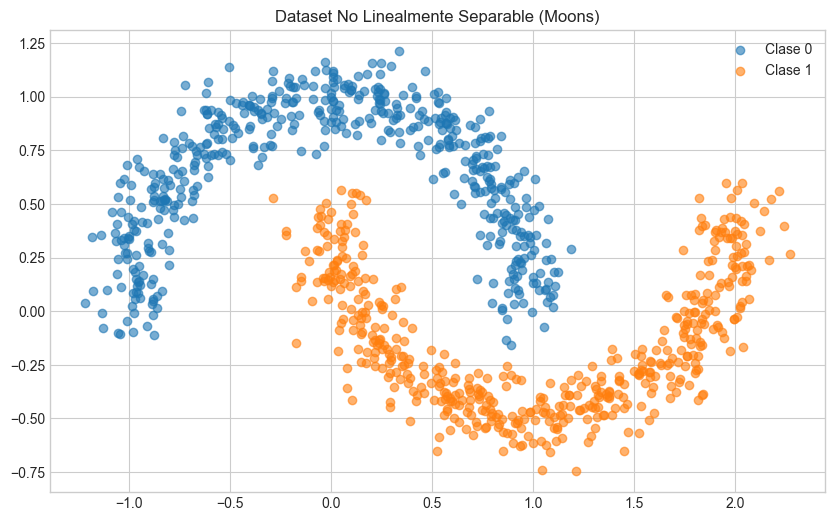

In [2]:
# Generamos datos en forma de luna
X, y = make_moons(n_samples=1000, noise=0.1, random_state=42)

# Dividimos en entrenamiento y testeo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Clase 0", alpha=0.6)
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Clase 1", alpha=0.6)
plt.title("Dataset No Linealmente Separable (Moons)")
plt.legend()
plt.show()

## 2. Limitación del Modelo Lineal

Primero, intentemos resolver esto con una única neurona (lo que vimos en la clase 6). Noten que aunque usemos TensorFlow, si no agregamos capas ocultas con funciones de activación no lineales, el resultado será una línea recta.

In [3]:
# Modelo de una sola neurona (Logístico)
model_linear = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation='sigmoid', input_shape=(2,))
])

model_linear.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_linear.fit(X_train, y_train, epochs=100, verbose=0, batch_size=32)

print(f"Precisión en test (Lineal): {model_linear.evaluate(X_test, y_test, verbose=0)[1]*100:.2f}%")

/Users/facundolucianna/Docencia/UNSTA/Procesamiento/Repo/signal-processing-bioengineering-unsta/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Precisión en test (Lineal): 86.33%


## 3. Construyendo una MLP

Ahora implementamos una red con capas ocultas. Como vimos en la diapositiva 8, la clave es usar una función de activación no lineal como **ReLU** en las capas ocultas.

In [4]:
# Definimos una MLP con capas ocultas
model_mlp = tf.keras.Sequential([
    # Capa oculta 1: 16 neuronas, activación ReLU
    tf.keras.layers.Dense(16, activation='relu', input_shape=(2,)),
    # Capa oculta 2: 8 neuronas, activación ReLU
    tf.keras.layers.Dense(8, activation='relu'),
    # Capa de salida: 1 neurona (clasificación binaria), activación sigmoide
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_mlp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model_mlp.fit(X_train, y_train, epochs=200, verbose=0, batch_size=32, validation_split=0.2)

print(f"Precisión en test (MLP): {model_mlp.evaluate(X_test, y_test, verbose=0)[1]*100:.2f}%")

Precisión en test (MLP): 100.00%


### Visualización de las Fronteras

Comparemos visualmente cómo el modelo lineal se queda corto frente a la flexibilidad de la MLP.

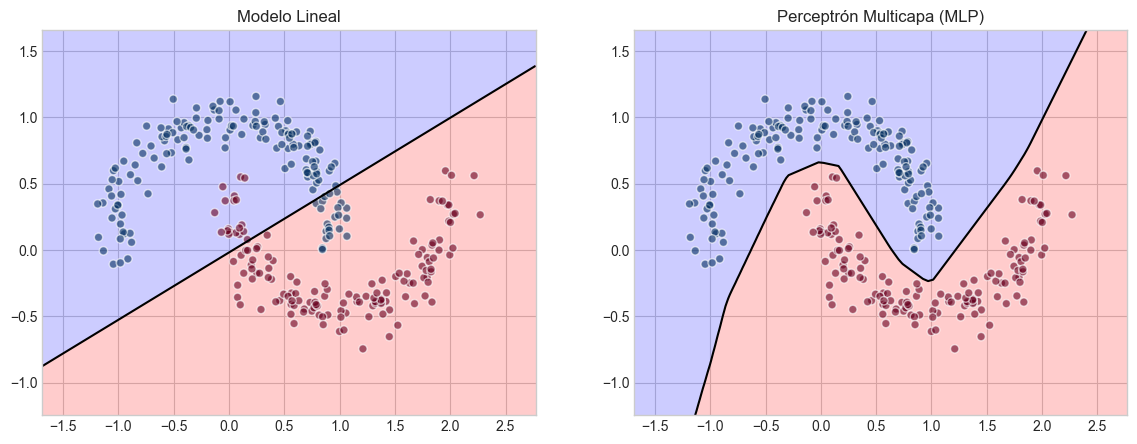

In [5]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0)
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], alpha=0.2, colors=['blue', 'red'])
    plt.contour(xx, yy, Z, levels=[0.5], colors='black')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu_r, edgecolor='white', alpha=0.6)
    plt.title(title)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plot_decision_boundary(model_linear, X_test, y_test, "Modelo Lineal")

plt.subplot(1, 2, 2)
plot_decision_boundary(model_mlp, X_test, y_test, "Perceptrón Multicapa (MLP)")
plt.show()

## 4. Regularización: Dropout y L2

Cuando las redes se vuelven muy profundas o anchas, pueden memorizar el ruido de los datos de entrenamiento (**sobreajuste**). 

Como vimos en las diapositivas 37-40, el **Dropout** es una técnica muy efectiva que desactiva aleatoriamente neuronas durante el entrenamiento.

In [6]:
from tensorflow.keras import regularizers

model_reg = tf.keras.Sequential([
    # Capa densa con regularización L2 (Weight Decay)
    tf.keras.layers.Dense(64, activation='relu', 
                          kernel_regularizer=regularizers.l2(0.01), 
                          input_shape=(2,)),
    # Capa de Dropout: desactiva el 20% de las neuronas
    tf.keras.layers.Dropout(0.2),
    
    tf.keras.layers.Dense(32, activation='relu', 
                          kernel_regularizer=regularizers.l2(0.01)),
    tf.keras.layers.Dropout(0.2),
    
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_reg.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_reg = model_reg.fit(X_train, y_train, epochs=200, verbose=0, 
                            batch_size=32, validation_data=(X_test, y_test))

print("Modelo con Regularización Entrenado")

Modelo con Regularización Entrenado


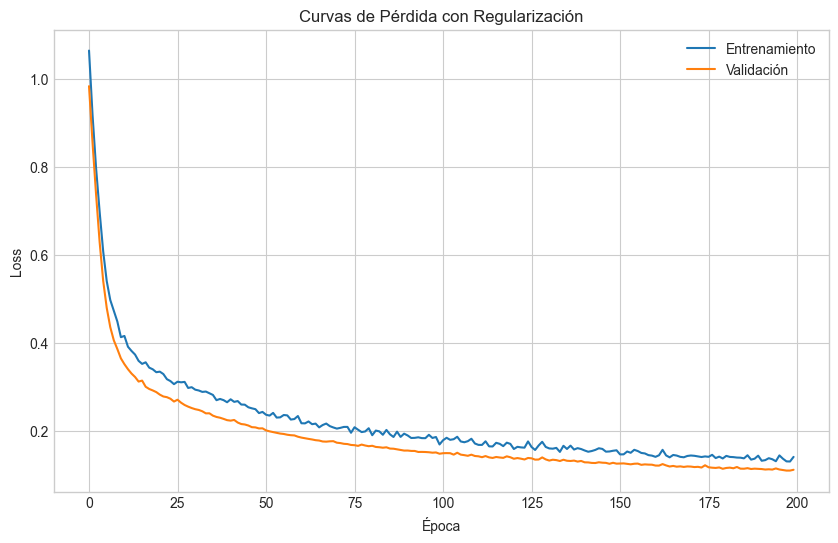

In [7]:
# Graficamos las curvas de aprendizaje
plt.plot(history_reg.history['loss'], label='Entrenamiento')
plt.plot(history_reg.history['val_loss'], label='Validación')
plt.title("Curvas de Pérdida con Regularización")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()